# Capítulo 23 (módulo extra) — Mudança Climática: laboratório numérico

**Curso de Meteorologia Prática** — módulo complementar ao livro de R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0); a física de base está no Cap. 21 do livro.

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | forçante do CO$_2$: o logaritmo e os cenários | NumPy |
| 2 | duas caixas (superfície + oceano): a inércia do aquecimento | `solve_ivp` |
| 3 | orçamento de carbono: a linearidade TCRE e o que resta | NumPy |
| 4 | detecção: quando o sinal emerge do ruído? | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap23_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## Caso 1 — A forçante logarítmica do CO$_2$

As bandas do CO$_2$ já estão quase saturadas no centro (Cap. 2): cada duplicação alarga as asas por um incremento ~constante:
$$\Delta F = 5{,}35\,\ln\frac{C}{C_0}\ \mathrm{W/m^2}\qquad(\Delta F_{2\times} = 3{,}7\ \mathrm{W/m^2}).$$
Com a sensibilidade $\lambda$ (Cap. 21, T2): $\Delta T_{eq} = \lambda\,\Delta F$.

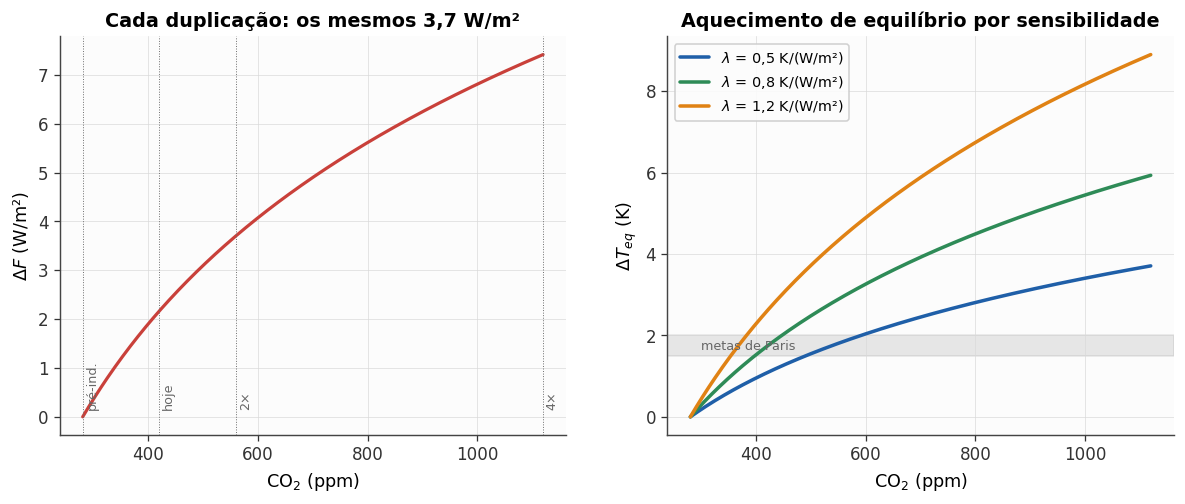

hoje (~420 ppm): dF = 2.2 W/m² -> 1,7-2,6 K de
equilibrio conforme lambda — ja comprometidos se o CO2 estacionar aqui.
(Observado ate agora: ~1,2 K — o oceano ainda deve o resto: Caso 2.)


In [2]:
C0 = 280.0
C = np.linspace(280, 1120, 300)
dF = 5.35*np.log(C/C0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax1.plot(C, dF, color=CORES['vermelho'], lw=2)
for cc, nome in [(280, 'pré-ind.'), (420, 'hoje'), (560, '2×'), (1120, '4×')]:
    ax1.axvline(cc, color=CORES['cinza'], lw=0.6, ls=':')
    ax1.text(cc + 5, 0.2, nome, fontsize=8, rotation=90, color='#666666')
ax1.set(xlabel='CO$_2$ (ppm)', ylabel='$\\Delta F$ (W/m²)',
        title='Cada duplicação: os mesmos 3,7 W/m²')
for lam, cor in [(0.5, CORES['azul']), (0.8, CORES['verde']), (1.2, CORES['laranja'])]:
    ax2.plot(C, lam*dF, color=cor, label=f'$\\lambda$ = {lam} K/(W/m²)'.replace('.', ','))
ax2.axhspan(1.5, 2.0, color=CORES['cinza'], alpha=0.15)
ax2.text(300, 1.65, 'metas de Paris', fontsize=8, color='#666666')
ax2.set(xlabel='CO$_2$ (ppm)', ylabel='$\\Delta T_{eq}$ (K)',
        title='Aquecimento de equilíbrio por sensibilidade')
ax2.legend(fontsize=9)
plt.show()
print(f'hoje (~420 ppm): dF = {5.35*np.log(420/280):.1f} W/m² -> 1,7-2,6 K de')
print('equilibrio conforme lambda — ja comprometidos se o CO2 estacionar aqui.')
print('(Observado ate agora: ~1,2 K — o oceano ainda deve o resto: Caso 2.)')

## Caso 2 — Duas caixas: por que o aquecimento atrasa

Superfície (rasa, rápida) acoplada ao oceano profundo (enorme, lento):
$$c_s\dot T_s = \Delta F(t) - \frac{T_s}{\lambda} - \gamma(T_s - T_d),\qquad c_d\dot T_d = \gamma(T_s - T_d).$$
O oceano profundo é o freio — e a dívida: mesmo com forçante congelada, $T$ segue subindo décadas.

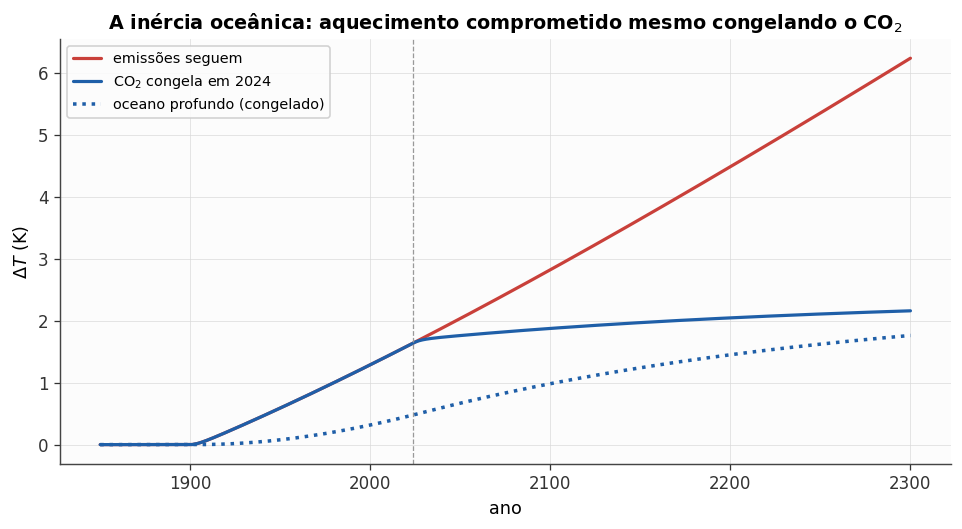

em 2024: 1.64 K; um seculo depois (CO2 congelado): 1.92 K
a diferenca e o aquecimento COMPROMETIDO: o oceano profundo cobra a divida
por seculos — o custo da inercia termica de 4 km de agua (Cap. 3!).


In [3]:
cs, cd = 8.0, 110.0                             # W·ano/m²/K
lam, gam = 0.8, 0.7                             # K/(W/m²), W/m²/K
anos = np.arange(1850, 2301)

def forc(t, cenario):
    if cenario == 'congela2024':
        C = np.where(t < 2024, 280*np.exp(0.0045*np.maximum(t - 1900, 0)), 
                     280*np.exp(0.0045*124))
    elif cenario == 'segue':
        C = 280*np.exp(0.0045*np.maximum(t - 1900, 0))
    return 5.35*np.log(C/280)

def duascaixas(cenario):
    def rhs(t, y):
        Ts, Td = y
        F = forc(np.array([t]), cenario)[0]
        return [(F - Ts/lam - gam*(Ts - Td))/cs, gam*(Ts - Td)/cd]
    return solve_ivp(rhs, [1850, 2300], [0, 0], t_eval=anos, rtol=1e-8)

s1 = duascaixas('segue')
s2 = duascaixas('congela2024')

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(anos, s1.y[0], color=CORES['vermelho'], lw=2, label='emissões seguem')
ax.plot(anos, s2.y[0], color=CORES['azul'], lw=2, label='CO$_2$ congela em 2024')
ax.plot(anos, s2.y[1], ':', color=CORES['azul'], label='oceano profundo (congelado)')
ax.axvline(2024, color='#999999', lw=0.8, ls='--')
ax.set(xlabel='ano', ylabel='$\\Delta T$ (K)',
       title='A inércia oceânica: aquecimento comprometido mesmo congelando o CO$_2$')
ax.legend(fontsize=9)
plt.show()
i24 = np.argmin(np.abs(anos - 2024)); i100 = np.argmin(np.abs(anos - 2124))
print(f'em 2024: {s2.y[0][i24]:.2f} K; um seculo depois (CO2 congelado): '
      f'{s2.y[0][i100]:.2f} K')
print('a diferenca e o aquecimento COMPROMETIDO: o oceano profundo cobra a divida')
print('por seculos — o custo da inercia termica de 4 km de agua (Cap. 3!).')

## Caso 3 — O orçamento de carbono

Resultado notável dos modelos: o aquecimento é ~proporcional às **emissões acumuladas** (TCRE ≈ 0,45 K por 1000 GtCO$_2$), independente da trajetória. Isso transforma metas de temperatura em orçamentos finitos.

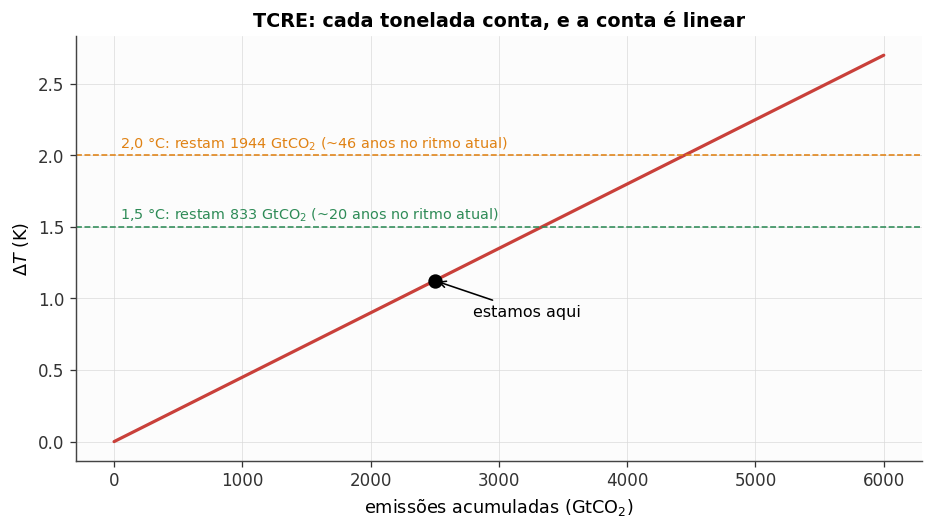

a linearidade (T4) junta dois efeitos que se cancelam: o log da forcante
e a saturacao dos sumidouros. Consequencia dura: estabilizar T exige
emissao liquida ZERO — nao basta parar de crescer.


In [4]:
TCRE = 0.45e-3                                  # K por GtCO2
E_hist = 2500.0                                 # GtCO2 emitidos ate ~2024
T_hist = TCRE*E_hist
E_ano = 42.0                                    # GtCO2/ano atuais

E = np.linspace(0, 6000, 200)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(E, TCRE*E, color=CORES['vermelho'], lw=2)
ax.plot(E_hist, T_hist, 'o', ms=8, color='k')
ax.annotate('estamos aqui', xy=(E_hist, T_hist), xytext=(E_hist + 300, T_hist - 0.25),
            fontsize=10, arrowprops=dict(arrowstyle='->'))
for meta, cor in [(1.5, CORES['verde']), (2.0, CORES['laranja'])]:
    E_meta = meta/TCRE
    ax.axhline(meta, color=cor, ls='--', lw=1)
    resta = E_meta - E_hist
    ax.text(50, meta + 0.05, f'{meta} °C: restam {resta:.0f} GtCO$_2$ '
            f'(~{resta/E_ano:.0f} anos no ritmo atual)'.replace('.', ','),
            fontsize=9, color=cor)
ax.set(xlabel='emissões acumuladas (GtCO$_2$)', ylabel='$\\Delta T$ (K)',
       title='TCRE: cada tonelada conta, e a conta é linear')
plt.show()
print('a linearidade (T4) junta dois efeitos que se cancelam: o log da forcante')
print('e a saturacao dos sumidouros. Consequencia dura: estabilizar T exige')
print('emissao liquida ZERO — nao basta parar de crescer.')

## Caso 4 — Detecção: o sinal emergindo do ruído

A variabilidade natural (ENSO, vulcões — Cap. 21) esconde a tendência por décadas. Sintetizamos séries com o mesmo espectro de ruído e perguntamos: **quando** a tendência se torna estatisticamente inegável?

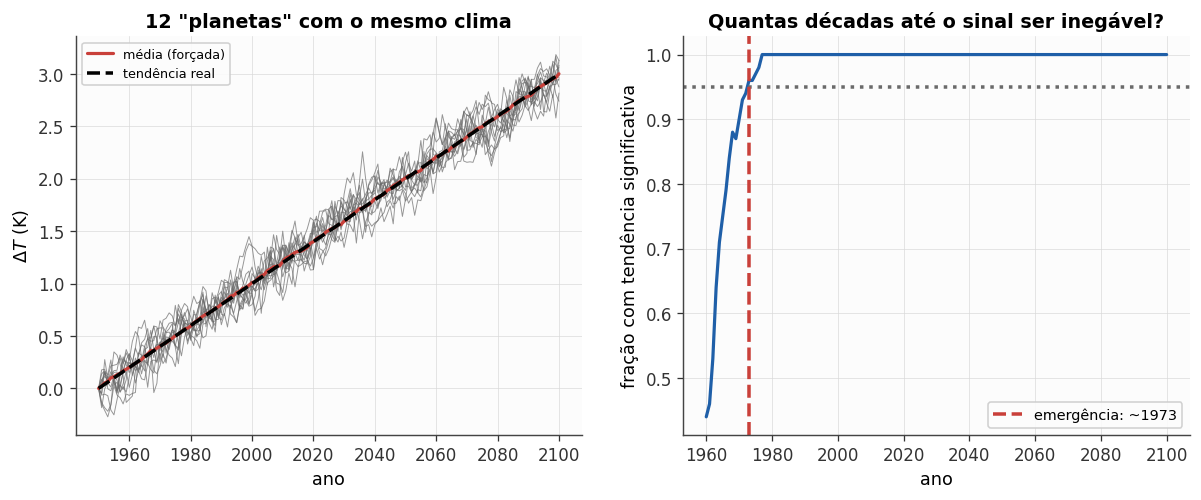

com ruido ENSO-like, ~23 anos de dados para 95% de deteccao:
e por isso que a atribuicao so ficou robusta nos anos 1990-2000, e por que
uma decada "fria" isolada nao refuta nada — o teste e sempre multidecadal.


In [5]:
rng = np.random.default_rng(22)
anos = np.arange(1950, 2101)
n = anos.size
tend = 0.02                                     # K/ano (~2 K/seculo)

def serie_ruido():
    # AR(1) com memoria interanual (ENSO-like)
    r = np.zeros(n); phi, sig = 0.6, 0.11
    for k in range(1, n):
        r[k] = phi*r[k-1] + sig*rng.standard_normal()
    return r

series = np.array([tend*(anos - anos[0]) + serie_ruido() for _ in range(200)])

# para cada ano, fração de séries cuja tendência até ali é significativa (t>2)
fracs = []
for m in range(10, n):
    ts = []
    x = anos[:m] - anos[0]
    for s in series[:100]:
        p, cov = np.polyfit(x, s[:m], 1, cov=True)
        ts.append(p[0]/np.sqrt(cov[0, 0]))
    fracs.append(np.mean(np.array(ts) > 2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax1.plot(anos, series[:12].T, lw=0.6, color=CORES['cinza'], alpha=0.7)
ax1.plot(anos, series.mean(0), color=CORES['vermelho'], lw=2, label='média (forçada)')
ax1.plot(anos, tend*(anos - anos[0]), '--', color='k', label='tendência real')
ax1.set(xlabel='ano', ylabel='$\\Delta T$ (K)', title='12 "planetas" com o mesmo clima')
ax1.legend(fontsize=8)
ax2.plot(anos[10:], fracs, color=CORES['azul'], lw=2)
ax2.axhline(0.95, color=CORES['cinza'], ls=':')
i95 = np.argmax(np.array(fracs) > 0.95)
ax2.axvline(anos[10 + i95], color=CORES['vermelho'], ls='--',
            label=f'emergência: ~{anos[10 + i95]}')
ax2.set(xlabel='ano', ylabel='fração com tendência significativa',
        title='Quantas décadas até o sinal ser inegável?')
ax2.legend(fontsize=9)
plt.show()
print(f'com ruido ENSO-like, ~{anos[10 + i95] - 1950} anos de dados para 95% de deteccao:')
print('e por isso que a atribuicao so ficou robusta nos anos 1990-2000, e por que')
print('uma decada "fria" isolada nao refuta nada — o teste e sempre multidecadal.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap23_solucoes.ipynb`**.

**N1** — Ajuste $\Delta F = a\ln(C/C_0)$ a uma 'linha por linha' sintética (fornecida no enunciado: banda saturada + asas) e recupere o $a \approx 5{,}35$; onde o log falha (concentrações muito baixas)?

**N2** — No modelo de duas caixas, varra $\lambda$ (0,5–1,2) e $\gamma$ e trace o aquecimento comprometido em 2124 para o cenário 'congela 2024'; qual parâmetro domina a dívida?

**N3** — Construa três trajetórias de emissão com as MESMAS emissões acumuladas (pico cedo, constante, pico tarde) e rode-as no modelo de duas caixas com forçante TCRE-consistente; o pico de temperatura difere?

**N4** — Repita o Caso 4 com o dobro e a metade da variância do ruído (planeta mais/menos 'ENSO-ativo') e trace o ano de emergência contra a amplitude do ruído.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*